In [20]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [21]:
train = pd.read_csv ('data/train.csv')
train.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## Understanding Data

In [22]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [5]:
train.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [6]:
train.describe(include='object')

,Driver,Compound,Race
count,439140,439140,439140
unique,887,5,26
top,MAS,MEDIUM,Dutch Grand Prix
freq,1682,211141,24462


### Check Target Distribution

In [7]:
target_counts = train['PitNextLap'].value_counts().sort_index()
target_counts

PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64

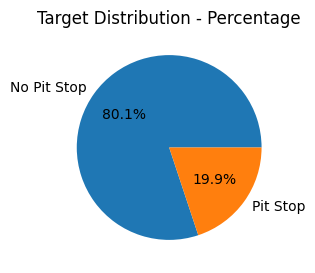

In [8]:
plt.figure(figsize=(6, 3))

plt.pie(target_counts.values, labels=['No Pit Stop', 'Pit Stop'], autopct='%1.1f%%')

plt.title('Target Distribution - Percentage')
plt.show()

#### Class Imbalance
- Severe class imbalance: 80% class 0, 20% class 1
- Use stratified cross-validation to maintain class balance
- Optimize for AUC-ROC (not accuracy)
- Consider class weights or SMOTE for balancing

### Segregating Numerical and Categorical Features

In [9]:
num_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = train.select_dtypes(include=['object', 'category']).columns.tolist()

In [10]:
num_cols, cat_cols

(['id',
  'Year',
  'PitStop',
  'LapNumber',
  'Stint',
  'TyreLife',
  'Position',
  'LapTime (s)',
  'LapTime_Delta',
  'Cumulative_Degradation',
  'RaceProgress',
  'Position_Change',
  'PitNextLap'],
 ['Driver', 'Compound', 'Race'])

In [11]:
num_cols = num_cols[1:]
num_cols

['Year',
 'PitStop',
 'LapNumber',
 'Stint',
 'TyreLife',
 'Position',
 'LapTime (s)',
 'LapTime_Delta',
 'Cumulative_Degradation',
 'RaceProgress',
 'Position_Change',
 'PitNextLap']

### Univariate Analysis

Analyzing 12 numerical features: ['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']



Analyzing 12 numerical features: ['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']



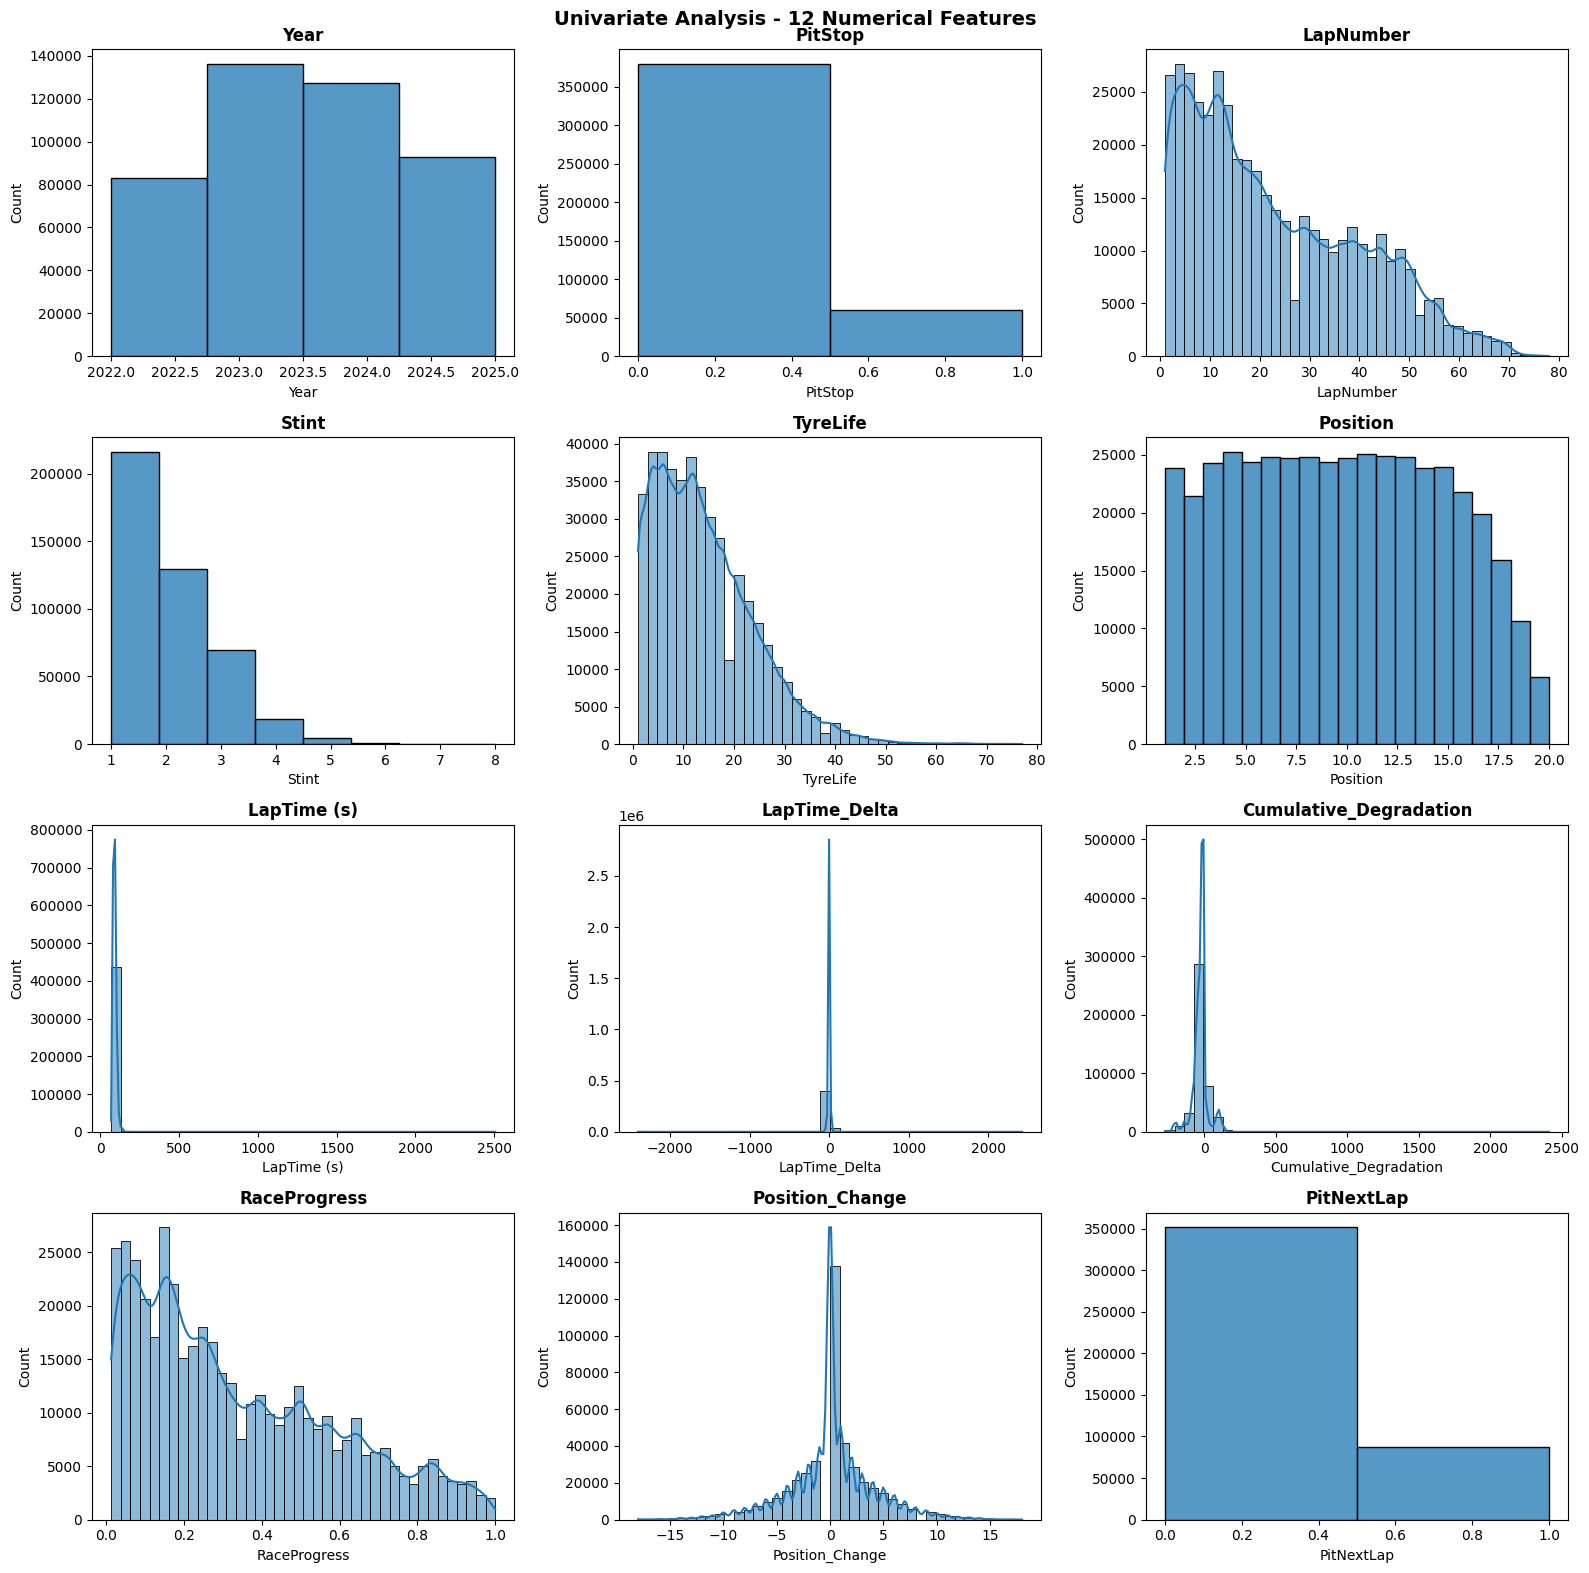

In [12]:
# Univariate Analysis for all numerical columns
print(f"Analyzing {len(num_cols)} numerical features: {num_cols}\n")

# Calculate grid dimensions
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()  # Flatten to 1D for easier iteration
fig.suptitle(f'Univariate Analysis - {len(num_cols)} Numerical Features', fontweight='bold', fontsize=14)

# Plot each numerical feature
for idx, col in enumerate(num_cols):
    ax = axes[idx]
    
    # Check if continuous or discrete
    n_unique = train[col].nunique()
    if n_unique > 20:  # Continuous - use KDE
        sns.histplot(data=train, x=col, kde=True, ax=ax, bins=40)
    else:  # Discrete - no KDE
        sns.histplot(data=train, x=col, ax=ax, bins=min(n_unique, 20))
    
    ax.set_title(f'{col}', fontweight='bold')

# Hide remaining empty subplots
for idx in range(len(num_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


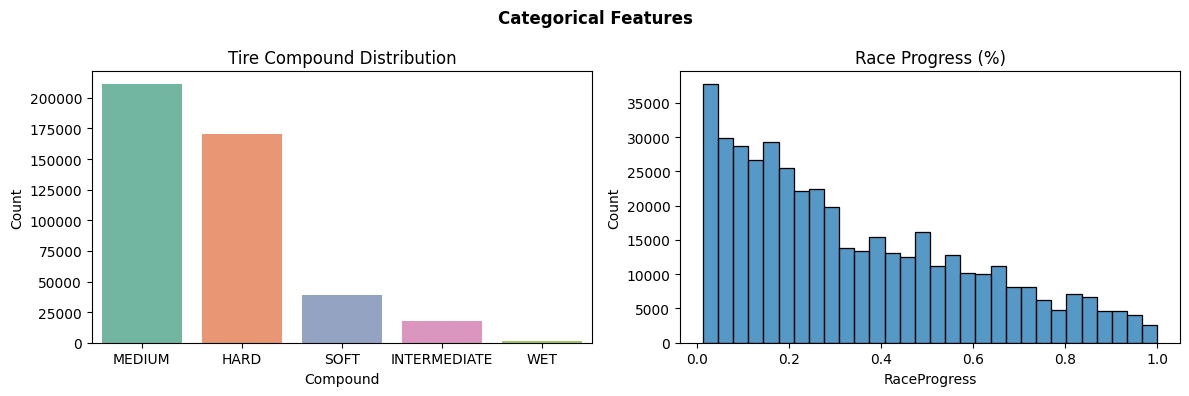

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Categorical Features', fontweight='bold')

# 1. Tire Compound
compound_counts = train['Compound'].value_counts()
sns.barplot(x=compound_counts.index, y=compound_counts.values, ax=axes[0], hue=compound_counts.index, palette='Set2', legend=False)
axes[0].set_title('Tire Compound Distribution')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Compound')

# 2. Race Progress
sns.histplot(data=train, x='RaceProgress', bins=30, ax=axes[1])
axes[1].set_title('Race Progress (%)')

plt.tight_layout()
plt.show()


BIVARIATE ANALYSIS: RaceProgress vs Tire Compound


BIVARIATE ANALYSIS: RaceProgress vs Tire Compound


C:\Users\iaman\AppData\Local\Temp\ipykernel_18000\1885430092.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=train, x='Compound', y='RaceProgress', ax=ax, palette='Set2')
C:\Users\iaman\AppData\Local\Temp\ipykernel_18000\1885430092.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Compound', y='RaceProgress', ax=ax, palette='Set2')


BIVARIATE ANALYSIS: RaceProgress vs Tire Compound


C:\Users\iaman\AppData\Local\Temp\ipykernel_18000\1885430092.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=train, x='Compound', y='RaceProgress', ax=ax, palette='Set2')
C:\Users\iaman\AppData\Local\Temp\ipykernel_18000\1885430092.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Compound', y='RaceProgress', ax=ax, palette='Set2')


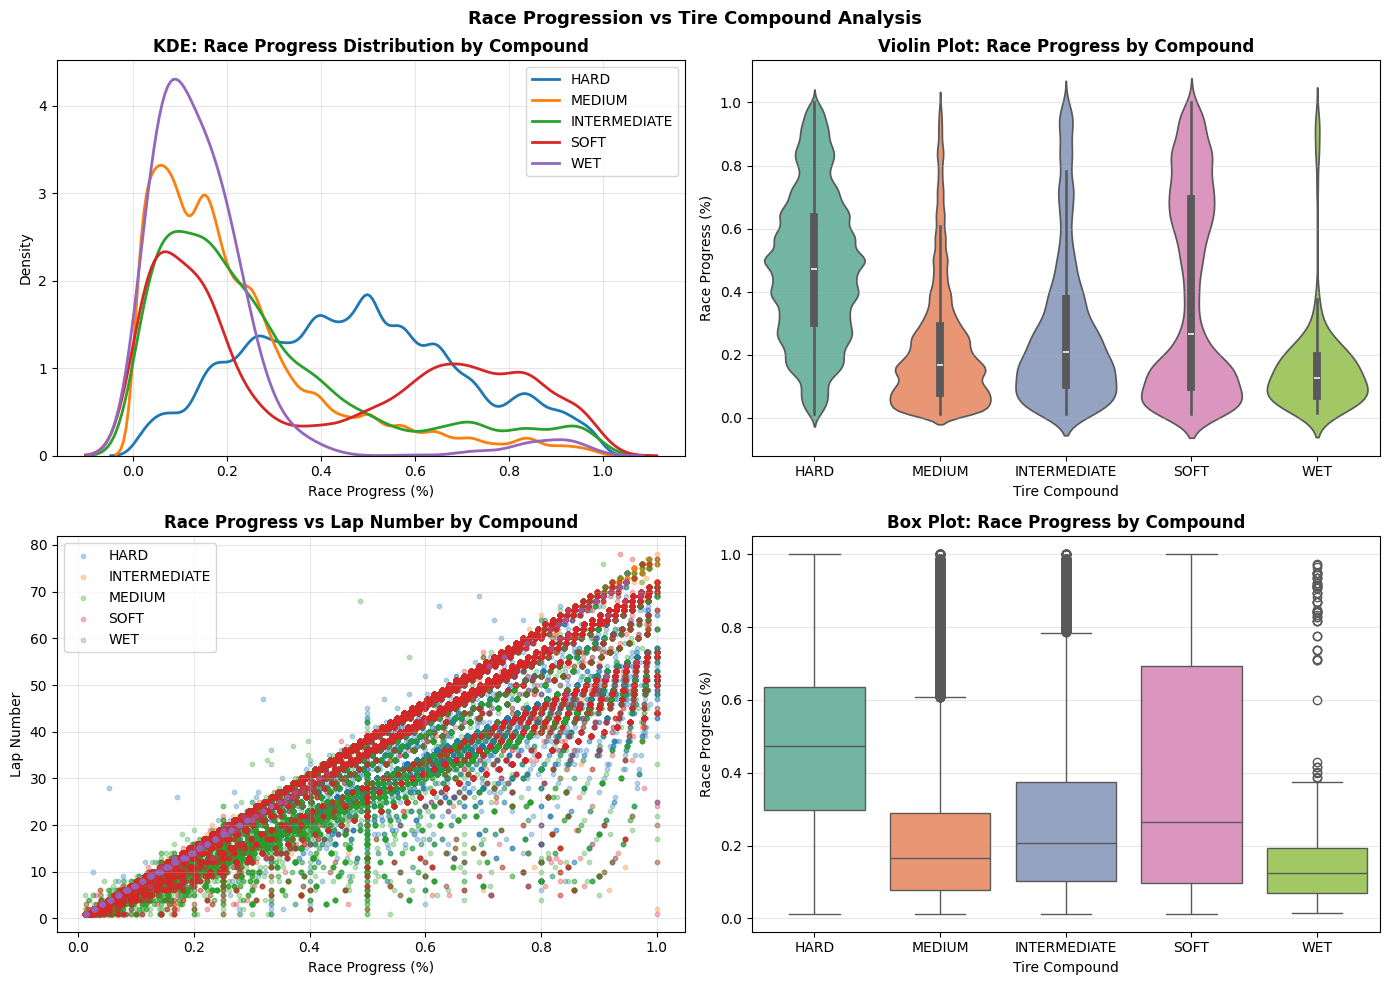

BIVARIATE ANALYSIS: RaceProgress vs Tire Compound


C:\Users\iaman\AppData\Local\Temp\ipykernel_18000\1885430092.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=train, x='Compound', y='RaceProgress', ax=ax, palette='Set2')
C:\Users\iaman\AppData\Local\Temp\ipykernel_18000\1885430092.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Compound', y='RaceProgress', ax=ax, palette='Set2')


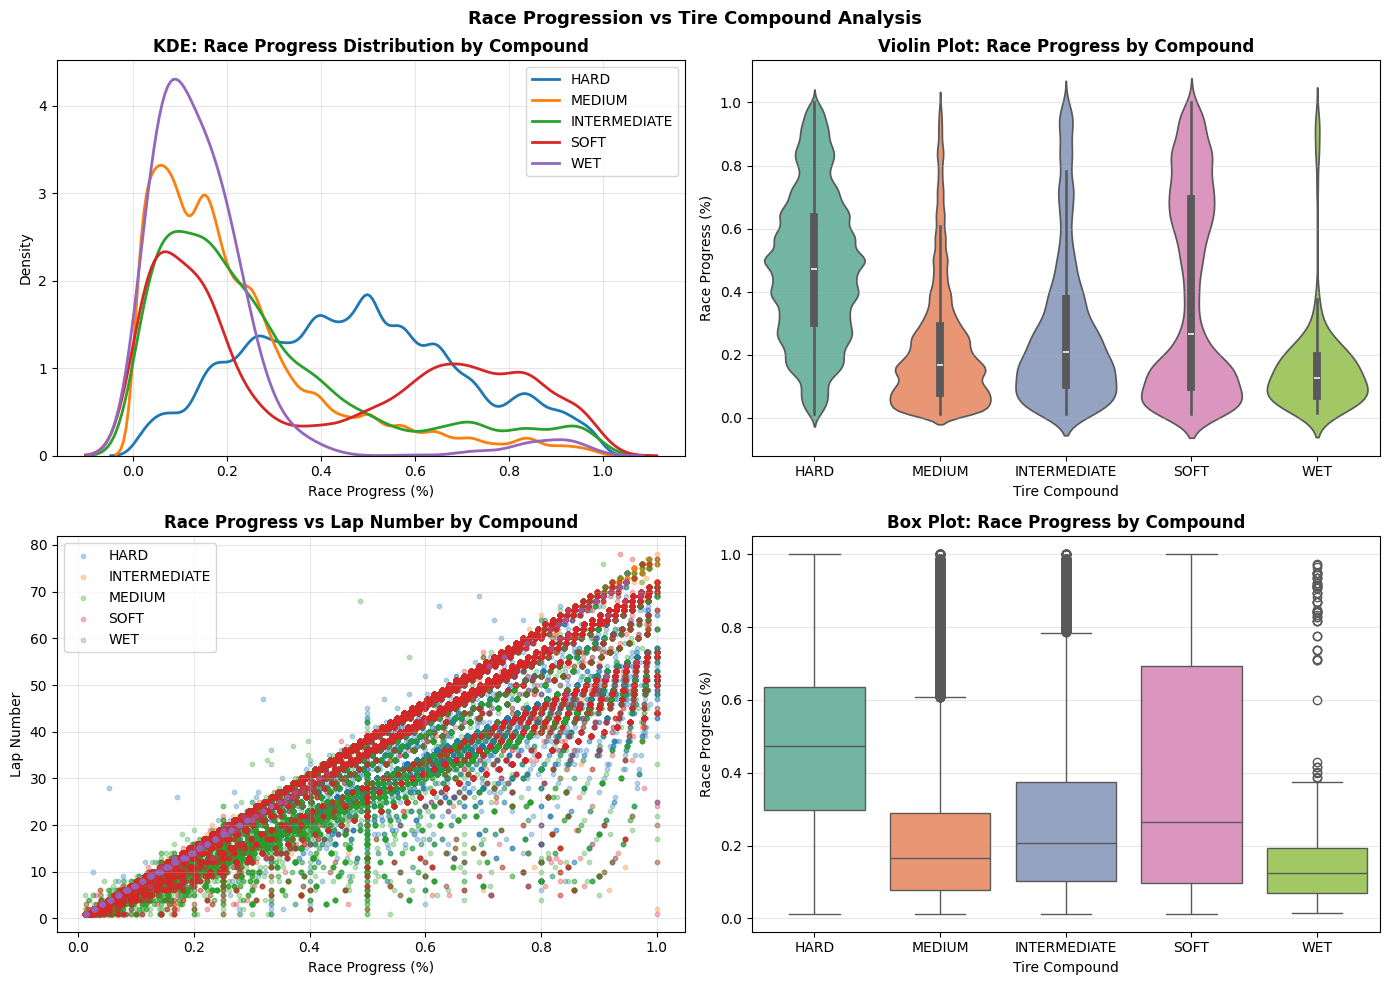


Race Progress Statistics by Tire Compound:
----------------------------------------------------------------------
               count      mean       std       min       max
Compound                                                    
HARD          170518  0.474730  0.227782  0.012821  1.000000
INTERMEDIATE   17382  0.280443  0.242476  0.012821  1.000000
MEDIUM        211141  0.222633  0.196401  0.012821  1.000000
SOFT           38744  0.393169  0.317490  0.012821  1.000000
WET             1355  0.159146  0.160499  0.013889  0.972222
----------------------------------------------------------------------


In [14]:
# BIVARIATE ANALYSIS: Race Progression vs Tire Compound
print("="*70)
print("BIVARIATE ANALYSIS: RaceProgress vs Tire Compound")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Race Progression vs Tire Compound Analysis', fontweight='bold', fontsize=13)

# 1. KDE Density Plot - Overlaid by Compound
ax = axes[0, 0]
for compound in train['Compound'].unique():
    data = train[train['Compound'] == compound]['RaceProgress']
    sns.kdeplot(data=data, ax=ax, label=compound, linewidth=2)
ax.set_title('KDE: Race Progress Distribution by Compound', fontweight='bold')
ax.set_xlabel('Race Progress (%)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

# 2. Violin Plot - Race Progress by Compound
ax = axes[0, 1]
sns.violinplot(data=train, x='Compound', y='RaceProgress', ax=ax, palette='Set2')
ax.set_title('Violin Plot: Race Progress by Compound', fontweight='bold')
ax.set_ylabel('Race Progress (%)')
ax.set_xlabel('Tire Compound')
ax.grid(alpha=0.3, axis='y')

# 3. KDE Density Plot 2D - RaceProgress colored by Compound
ax = axes[1, 0]
for compound in sorted(train['Compound'].unique()):
    data = train[train['Compound'] == compound]
    ax.scatter(data['RaceProgress'], data['LapNumber'], alpha=0.3, s=10, label=compound)
ax.set_title('Race Progress vs Lap Number by Compound', fontweight='bold')
ax.set_xlabel('Race Progress (%)')
ax.set_ylabel('Lap Number')
ax.legend()
ax.grid(alpha=0.3)

# 4. Box Plot - Distribution statistics
ax = axes[1, 1]
sns.boxplot(data=train, x='Compound', y='RaceProgress', ax=ax, palette='Set2')
ax.set_title('Box Plot: Race Progress by Compound', fontweight='bold')
ax.set_ylabel('Race Progress (%)')
ax.set_xlabel('Tire Compound')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print statistics by compound
print("\nRace Progress Statistics by Tire Compound:")
print("-" * 70)
stats = train.groupby('Compound')['RaceProgress'].agg(['count', 'mean', 'std', 'min', 'max'])
print(stats.to_string())
print("-" * 70)


### Outlier Detection

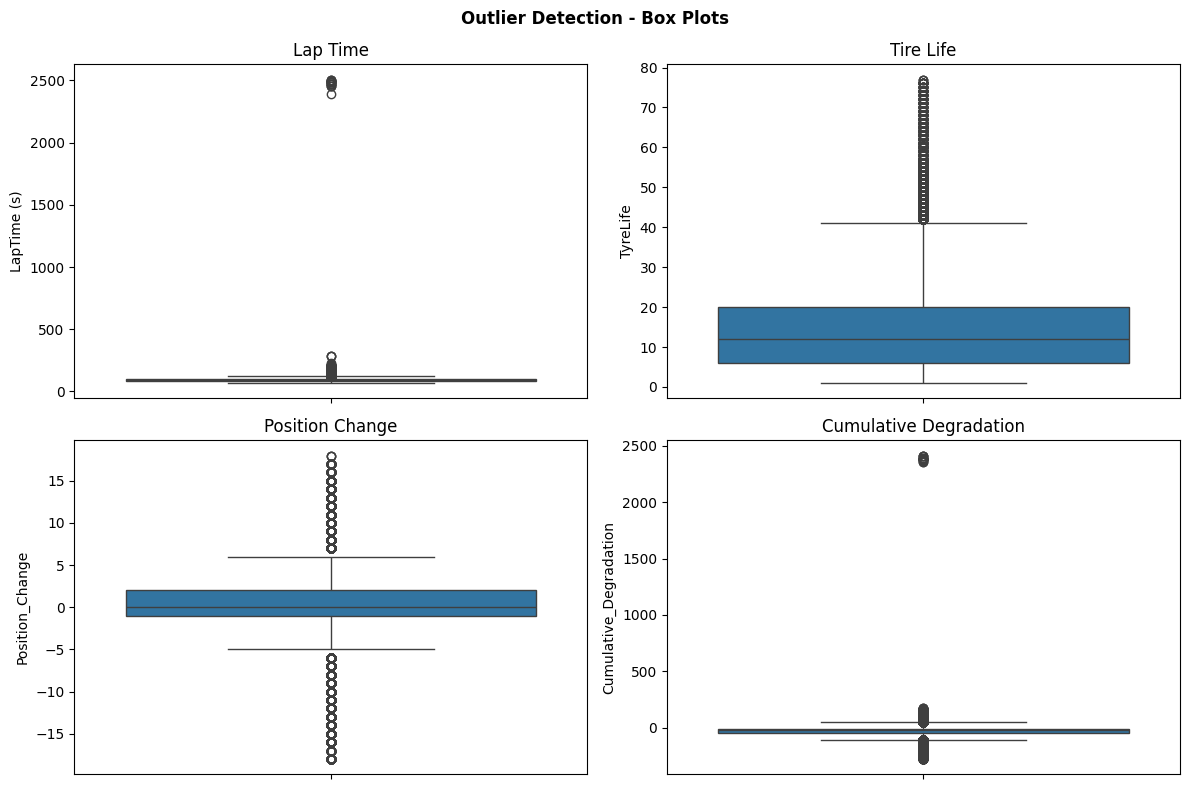

In [15]:
# Outlier Detection
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Outlier Detection - Box Plots', fontweight='bold')

# Lap Time
sns.boxplot(data=train, y='LapTime (s)', ax=axes[0, 0])
axes[0, 0].set_title('Lap Time')

# Tire Life
sns.boxplot(data=train, y='TyreLife', ax=axes[0, 1])
axes[0, 1].set_title('Tire Life')

# Position Change
sns.boxplot(data=train, y='Position_Change', ax=axes[1, 0])
axes[1, 0].set_title('Position Change')

# Cumulative Degradation
sns.boxplot(data=train, y='Cumulative_Degradation', ax=axes[1, 1])
axes[1, 1].set_title('Cumulative Degradation')

plt.tight_layout()
plt.show()

- Most features have moderate outlier presence (<5%)
- Action: Keep outliers (they may be important F1 scenarios)

### NUMERICAL - NUMERICAL CORRELATION

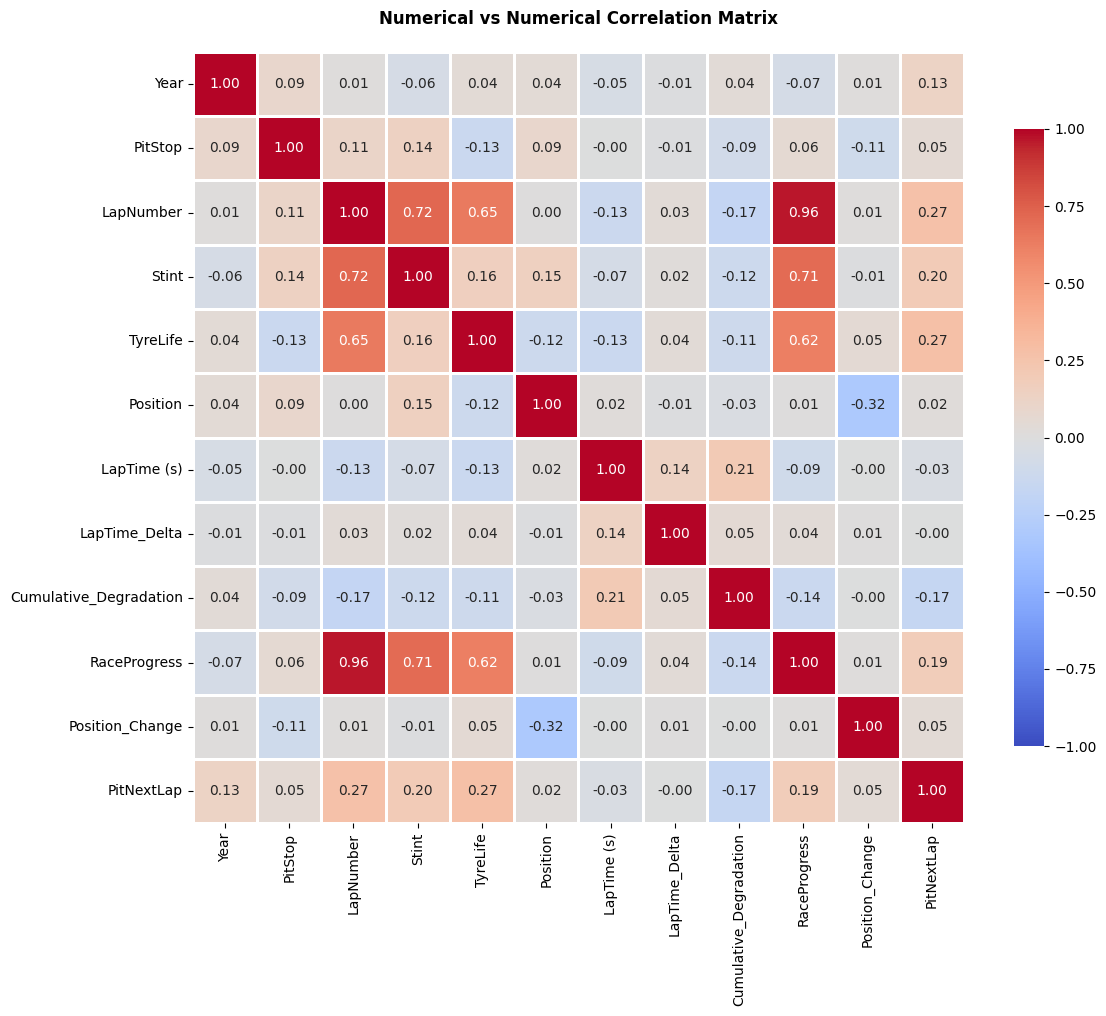

In [ ]:
# Pearson correlation for numerical features
num_corr = train[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(num_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Numerical vs Numerical Correlation Matrix', fontweight='bold', fontsize=12, pad=20)
plt.tight_layout()
plt.show()


### Bivariate Analysis: KDE Plots - Features vs Pit Stop Decision

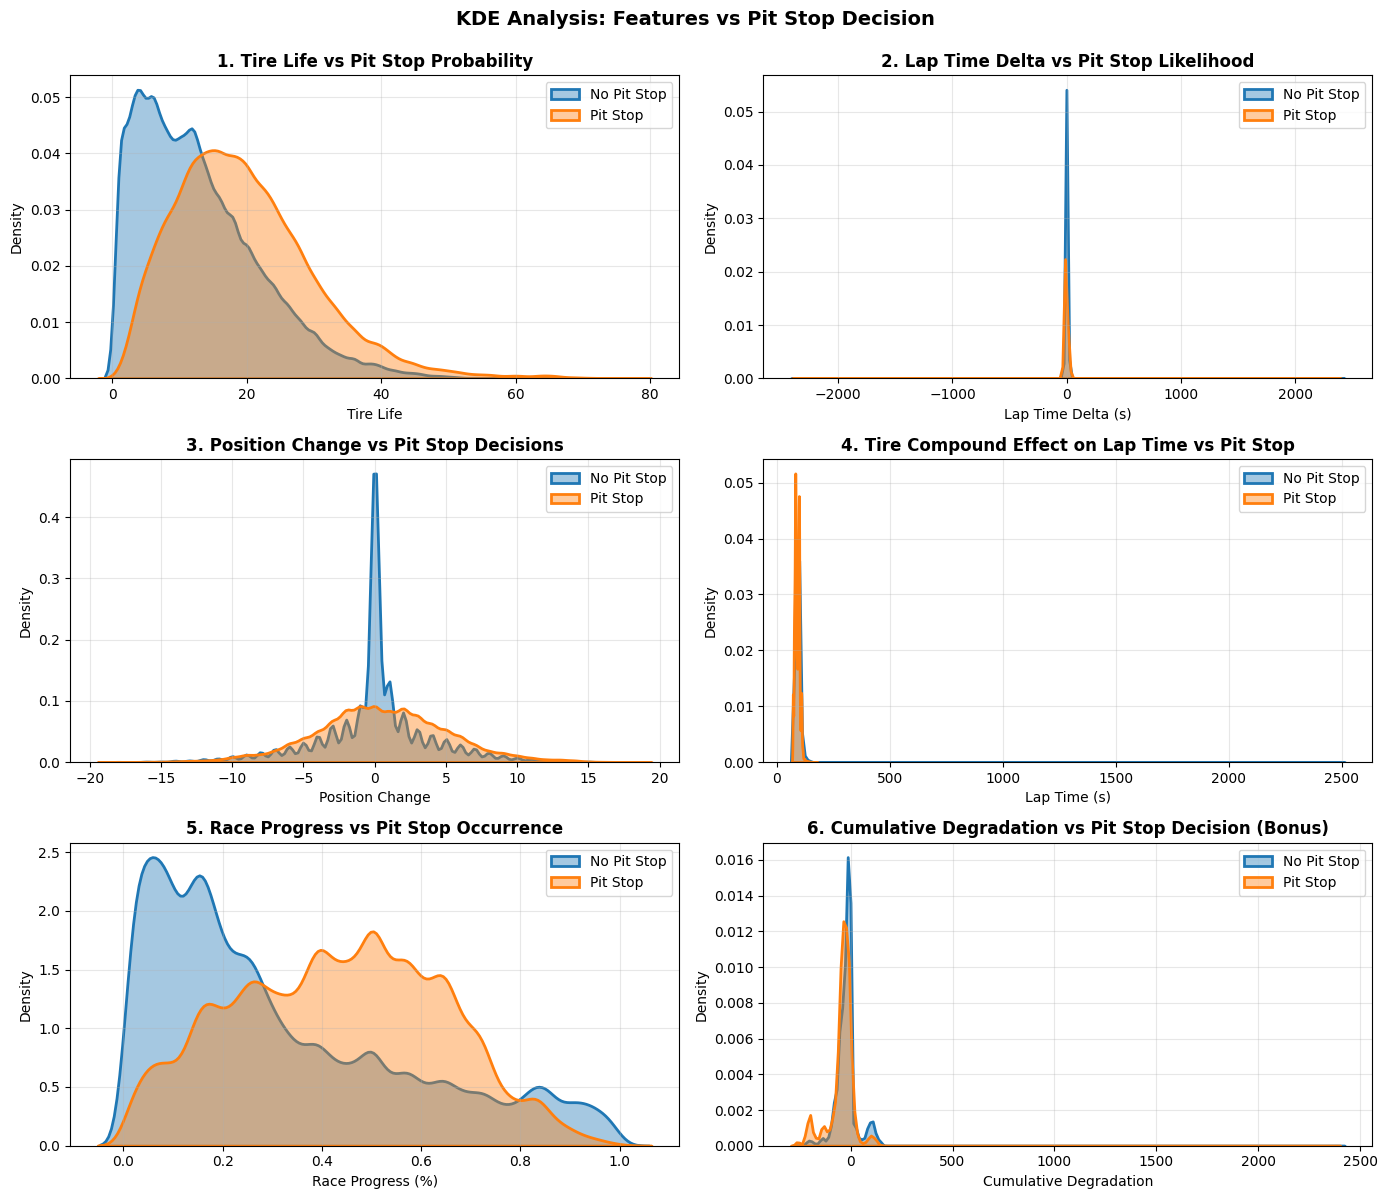

In [23]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('KDE Analysis: Features vs Pit Stop Decision', fontweight='bold', fontsize=14, y=0.995)

# 1. Tire Life vs Pit Stop Probability
ax = axes[0, 0]
for pit_status in sorted(train['PitNextLap'].unique()):
    data = train[train['PitNextLap'] == pit_status]['TyreLife'].dropna()
    label = 'Pit Stop' if pit_status == 1 else 'No Pit Stop'
    sns.kdeplot(data=data, ax=ax, label=label, linewidth=2, fill=True, alpha=0.4)
ax.set_title('1. Tire Life vs Pit Stop Probability', fontweight='bold')
ax.set_xlabel('Tire Life')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

# 2. Lap Time Delta vs Pit Stop Likelihood
ax = axes[0, 1]
for pit_status in sorted(train['PitNextLap'].unique()):
    data = train[train['PitNextLap'] == pit_status]['LapTime_Delta'].dropna()
    label = 'Pit Stop' if pit_status == 1 else 'No Pit Stop'
    sns.kdeplot(data=data, ax=ax, label=label, linewidth=2, fill=True, alpha=0.4)
ax.set_title('2. Lap Time Delta vs Pit Stop Likelihood', fontweight='bold')
ax.set_xlabel('Lap Time Delta (s)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

# 3. Position Change vs Pit Stop Decisions
ax = axes[1, 0]
for pit_status in sorted(train['PitNextLap'].unique()):
    data = train[train['PitNextLap'] == pit_status]['Position_Change'].dropna()
    label = 'Pit Stop' if pit_status == 1 else 'No Pit Stop'
    sns.kdeplot(data=data, ax=ax, label=label, linewidth=2, fill=True, alpha=0.4)
ax.set_title('3. Position Change vs Pit Stop Decisions', fontweight='bold')
ax.set_xlabel('Position Change')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

# 4. Tire Compound Choice vs Pit Stop Timing (by Lap Time)
ax = axes[1, 1]
for pit_status in sorted(train['PitNextLap'].unique()):
    data = train[train['PitNextLap'] == pit_status]['LapTime (s)'].dropna()
    label = 'Pit Stop' if pit_status == 1 else 'No Pit Stop'
    sns.kdeplot(data=data, ax=ax, label=label, linewidth=2, fill=True, alpha=0.4)
ax.set_title('4. Tire Compound Effect on Lap Time vs Pit Stop', fontweight='bold')
ax.set_xlabel('Lap Time (s)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

# 5. Race Progress vs Pit Stop Occurrence
ax = axes[2, 0]
for pit_status in sorted(train['PitNextLap'].unique()):
    data = train[train['PitNextLap'] == pit_status]['RaceProgress'].dropna()
    label = 'Pit Stop' if pit_status == 1 else 'No Pit Stop'
    sns.kdeplot(data=data, ax=ax, label=label, linewidth=2, fill=True, alpha=0.4)
ax.set_title('5. Race Progress vs Pit Stop Occurrence', fontweight='bold')
ax.set_xlabel('Race Progress (%)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

# 6. Cumulative Degradation (Bonus)
ax = axes[2, 1]
for pit_status in sorted(train['PitNextLap'].unique()):
    data = train[train['PitNextLap'] == pit_status]['Cumulative_Degradation'].dropna()
    label = 'Pit Stop' if pit_status == 1 else 'No Pit Stop'
    sns.kdeplot(data=data, ax=ax, label=label, linewidth=2, fill=True, alpha=0.4)
ax.set_title('6. Cumulative Degradation vs Pit Stop Decision (Bonus)', fontweight='bold')
ax.set_xlabel('Cumulative Degradation')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


#### Insights

1. Pit stops occur with higher tire life (left-skewed for pit stops vs right-skewed for no pit stops)

2. Sharp contrast between Lap Time Delta and Pit Stop Likelihood shows pit stops cluster near 0 (normal lap times) while no-pit laps have extreme variation

3. Both Position Change and Pit Stop distributions are centered at 0, but pit stops show more variance in position changes

4. Pit stops correlate with higher lap times, pit stops show significantly different timing patterns

5. Pit stops peak around 40-70% race progress, with multi-modal distribution patterns

6. Pit stops occur with lower cumulative degradation, indicating strategic timing before excessive tire wear

### Tire Compound Choice & Pit Stop Timing

C:\Users\iaman\AppData\Local\Temp\ipykernel_18000\477756701.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pit_rate.index, y=pit_rate.values, ax=ax, palette='viridis')


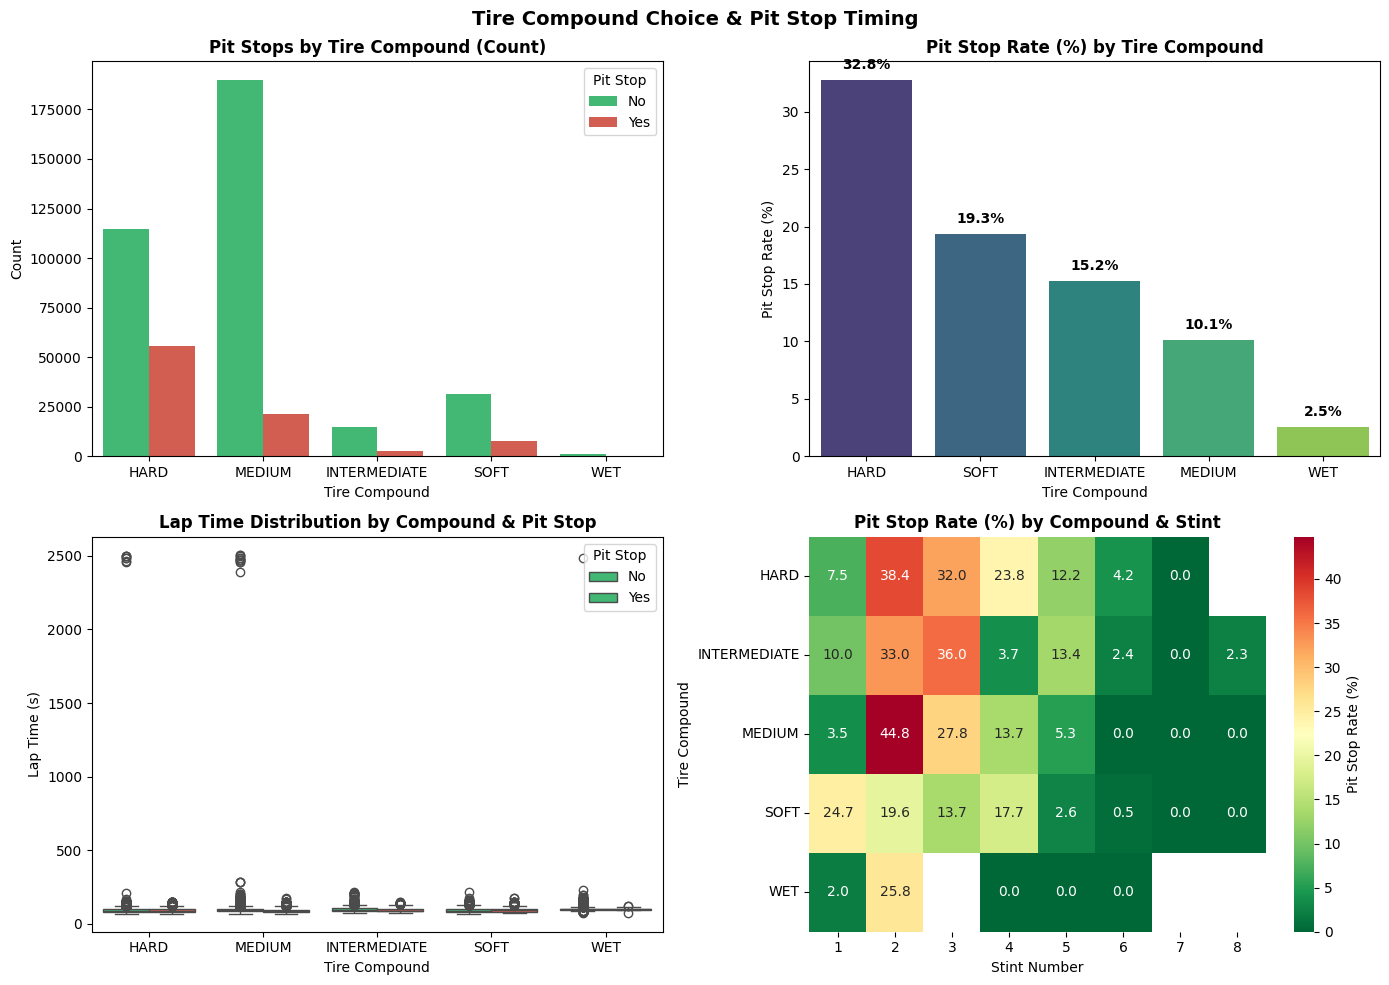

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Tire Compound Choice & Pit Stop Timing', fontweight='bold', fontsize=14)

# 1. Count Plot - Pit Stop by Tire Compound
ax = axes[0, 0]
sns.countplot(data=train, x='Compound', hue='PitNextLap', ax=ax, palette=['#2ecc71', '#e74c3c'])
ax.set_title('Pit Stops by Tire Compound (Count)', fontweight='bold')
ax.set_xlabel('Tire Compound')
ax.set_ylabel('Count')
ax.legend(title='Pit Stop', labels=['No', 'Yes'])

# 2. Bar Plot - Pit Stop Rate % by Compound
ax = axes[0, 1]
pit_rate = train.groupby('Compound')['PitNextLap'].agg(lambda x: (x.sum() / len(x) * 100)).sort_values(ascending=False)
sns.barplot(x=pit_rate.index, y=pit_rate.values, ax=ax, palette='viridis')
ax.set_title('Pit Stop Rate (%) by Tire Compound', fontweight='bold')
ax.set_xlabel('Tire Compound')
ax.set_ylabel('Pit Stop Rate (%)')
for i, v in enumerate(pit_rate.values):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# 3. Box Plot - Lap Time by Compound & Pit Stop
ax = axes[1, 0]
sns.boxplot(data=train, x='Compound', y='LapTime (s)', hue='PitNextLap', ax=ax, palette=['#2ecc71', '#e74c3c'])
ax.set_title('Lap Time Distribution by Compound & Pit Stop', fontweight='bold')
ax.set_xlabel('Tire Compound')
ax.set_ylabel('Lap Time (s)')
ax.legend(title='Pit Stop', labels=['No', 'Yes'])

# 4. Heatmap - Pit Stop Decision by Compound & Stint
ax = axes[1, 1]
pivot_table = pd.crosstab(train['Compound'], train['Stint'], train['PitNextLap'], aggfunc='mean') * 100
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax, cbar_kws={'label': 'Pit Stop Rate (%)'})
ax.set_title('Pit Stop Rate (%) by Compound & Stint', fontweight='bold')
ax.set_xlabel('Stint Number')
ax.set_ylabel('Tire Compound')

plt.tight_layout()
plt.show()

## Multivariate Analysis: Complex Relationships

C:\Users\iaman\AppData\Local\Temp\ipykernel_18000\2999833495.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=race_pit_stats.index, x=race_pit_stats['Pit_Rate(%)'], ax=ax2, palette='coolwarm')
C:\Users\iaman\AppData\Local\Temp\ipykernel_18000\2999833495.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=driver_pit_stats.index, x=driver_pit_stats['Pit_Rate(%)'], ax=ax3, palette='viridis')


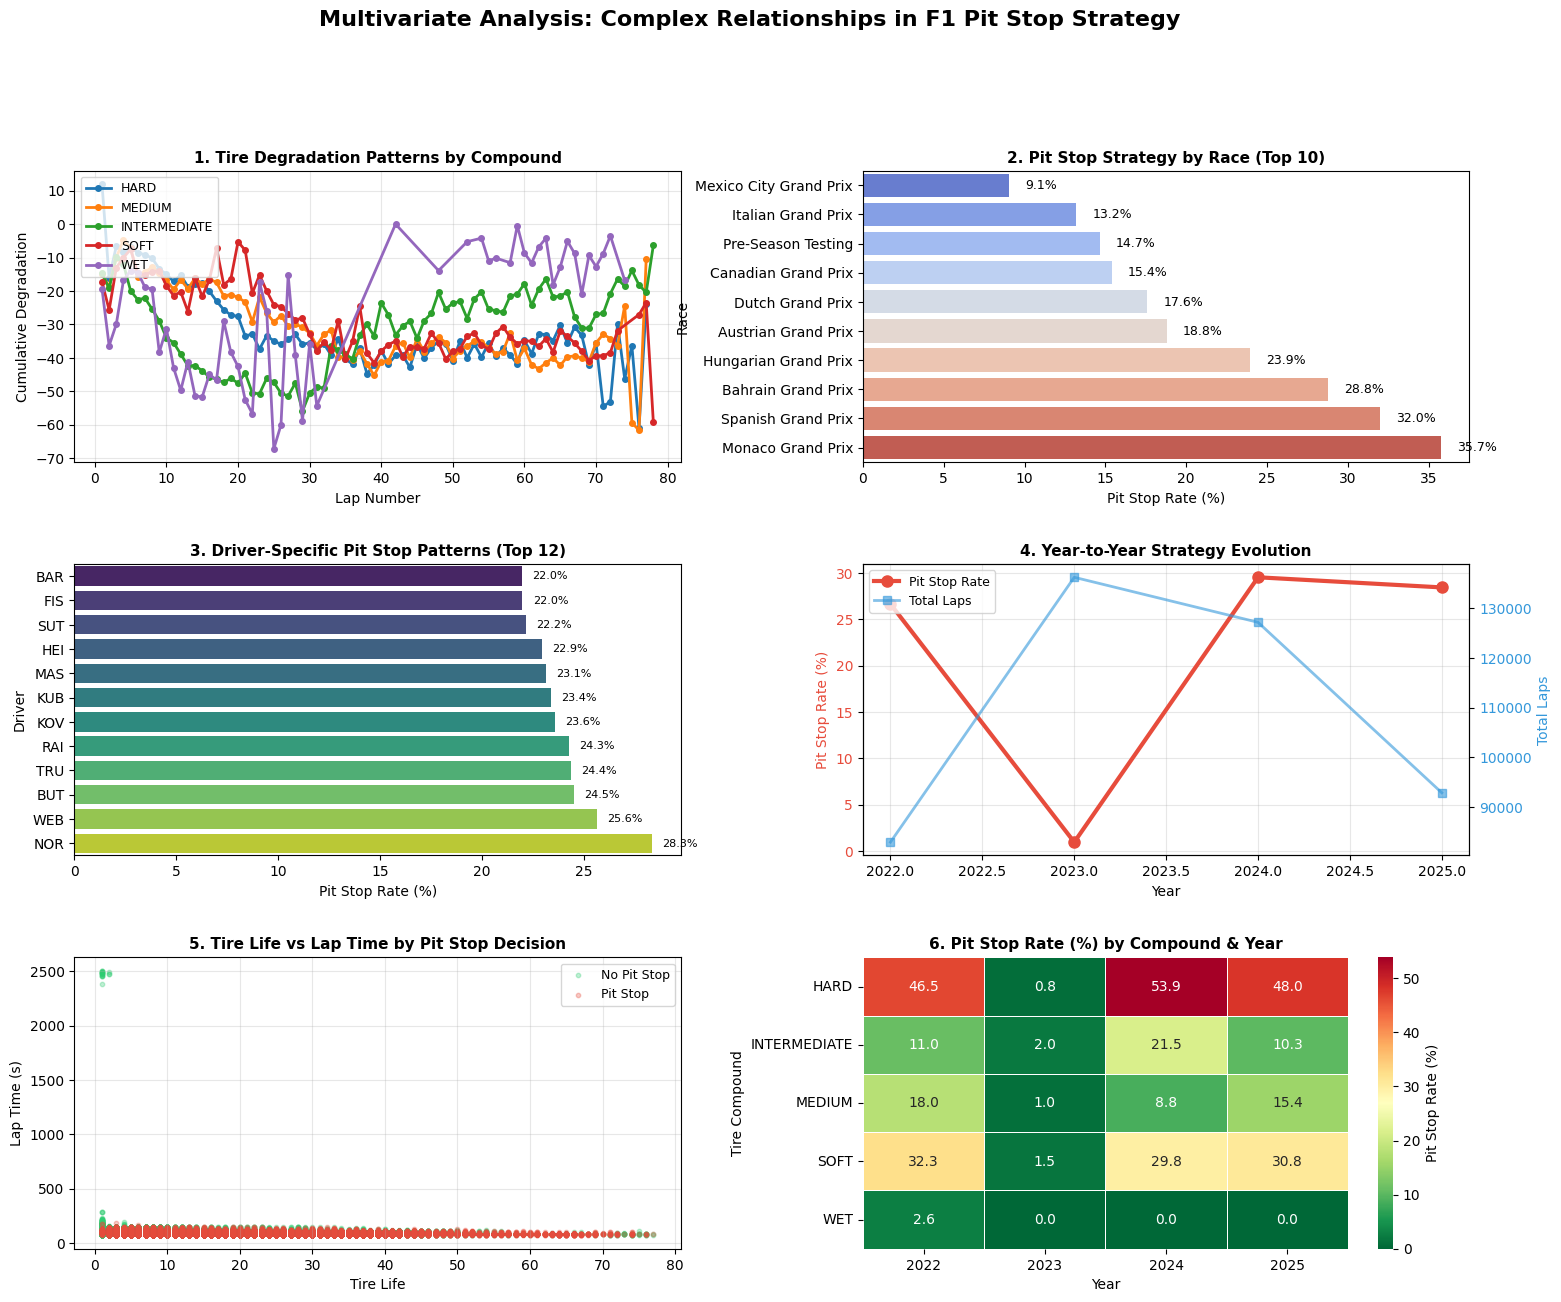

In [29]:
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

fig.suptitle('Multivariate Analysis: Complex Relationships in F1 Pit Stop Strategy', 
             fontweight='bold', fontsize=16, y=0.995)

# ============================================================================
# 1. TIRE DEGRADATION PATTERNS ACROSS DIFFERENT COMPOUNDS
# ============================================================================
ax1 = fig.add_subplot(gs[0, 0])
compound_degradation = train.groupby(['Compound', 'LapNumber'])['Cumulative_Degradation'].mean().reset_index()
for compound in train['Compound'].unique():
    data = compound_degradation[compound_degradation['Compound'] == compound]
    ax1.plot(data['LapNumber'], data['Cumulative_Degradation'], marker='o', label=compound, linewidth=2, markersize=4)
ax1.set_title('1. Tire Degradation Patterns by Compound', fontweight='bold', fontsize=11)
ax1.set_xlabel('Lap Number')
ax1.set_ylabel('Cumulative Degradation')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(alpha=0.3)

# ============================================================================
# 2. PIT STOP STRATEGY BY RACE/CIRCUIT
# ============================================================================
ax2 = fig.add_subplot(gs[0, 1])
# Get top 10 races
top_races = train['Race'].value_counts().head(10).index
race_pit_stats = train[train['Race'].isin(top_races)].groupby('Race')['PitNextLap'].agg(['count', 'sum', lambda x: (x.sum()/len(x)*100)]).rename(columns={'<lambda_0>': 'Pit_Rate(%)'})
race_pit_stats = race_pit_stats.sort_values('Pit_Rate(%)', ascending=True)
sns.barplot(y=race_pit_stats.index, x=race_pit_stats['Pit_Rate(%)'], ax=ax2, palette='coolwarm')
ax2.set_title('2. Pit Stop Strategy by Race (Top 10)', fontweight='bold', fontsize=11)
ax2.set_xlabel('Pit Stop Rate (%)')
ax2.set_ylabel('Race')
for i, v in enumerate(race_pit_stats['Pit_Rate(%)']):
    ax2.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)

# ============================================================================
# 3. DRIVER-SPECIFIC PIT STOP PATTERNS
# ============================================================================
ax3 = fig.add_subplot(gs[1, 0])
# Get top 12 drivers
top_drivers = train['Driver'].value_counts().head(12).index
driver_pit_stats = train[train['Driver'].isin(top_drivers)].groupby('Driver')['PitNextLap'].agg(['count', 'sum', lambda x: (x.sum()/len(x)*100)]).rename(columns={'<lambda_0>': 'Pit_Rate(%)'})
driver_pit_stats = driver_pit_stats.sort_values('Pit_Rate(%)', ascending=True)
sns.barplot(y=driver_pit_stats.index, x=driver_pit_stats['Pit_Rate(%)'], ax=ax3, palette='viridis')
ax3.set_title('3. Driver-Specific Pit Stop Patterns (Top 12)', fontweight='bold', fontsize=11)
ax3.set_xlabel('Pit Stop Rate (%)')
ax3.set_ylabel('Driver')
for i, v in enumerate(driver_pit_stats['Pit_Rate(%)']):
    ax3.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)

# ============================================================================
# 4. YEAR-TO-YEAR STRATEGY EVOLUTION 
# ============================================================================
ax4 = fig.add_subplot(gs[1, 1])
year_pit_stats = train.groupby('Year')['PitNextLap'].agg(['count', 'sum', lambda x: (x.sum()/len(x)*100)]).rename(columns={'<lambda_0>': 'Pit_Rate(%)'})
ax4_line = ax4.plot(year_pit_stats.index, year_pit_stats['Pit_Rate(%)'], marker='o', color='#e74c3c', linewidth=3, markersize=8, label='Pit Stop Rate')
ax4.set_title('4. Year-to-Year Strategy Evolution', fontweight='bold', fontsize=11)
ax4.set_xlabel('Year')
ax4.set_ylabel('Pit Stop Rate (%)', color='#e74c3c')
ax4.tick_params(axis='y', labelcolor='#e74c3c')
ax4.grid(alpha=0.3)
ax4.legend(loc='upper left')

# Add secondary axis for total races
ax4_sec = ax4.twinx()
ax4_sec_line = ax4_sec.plot(year_pit_stats.index, year_pit_stats['count'], marker='s', color='#3498db', linewidth=2, markersize=6, alpha=0.6, label='Total Laps')
ax4_sec.set_ylabel('Total Laps', color='#3498db')
ax4_sec.tick_params(axis='y', labelcolor='#3498db')
lines = ax4_line + ax4_sec_line
labels = [l.get_label() for l in lines]
ax4.legend(lines, labels, loc='upper left', fontsize=9)

# ============================================================================
# 5. COMPOUND vs LAP TIME vs PIT STOP 
# ============================================================================
ax5 = fig.add_subplot(gs[2, 0])
for pit_status in sorted(train['PitNextLap'].unique()):
    mask = train['PitNextLap'] == pit_status
    label = 'Pit Stop' if pit_status == 1 else 'No Pit Stop'
    color = '#e74c3c' if pit_status == 1 else '#2ecc71'
    ax5.scatter(train[mask]['TyreLife'], train[mask]['LapTime (s)'], 
               alpha=0.3, s=10, label=label, color=color)
ax5.set_title('5. Tire Life vs Lap Time by Pit Stop Decision', fontweight='bold', fontsize=11)
ax5.set_xlabel('Tire Life')
ax5.set_ylabel('Lap Time (s)')
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3)

# ============================================================================
# 6. HEATMAP - PIT STOP RATE BY COMPOUND AND YEAR 
# ============================================================================
ax6 = fig.add_subplot(gs[2, 1])
heatmap_data = pd.crosstab(train['Compound'], train['Year'], train['PitNextLap'], aggfunc='mean') * 100
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax6, 
            cbar_kws={'label': 'Pit Stop Rate (%)'}, linewidths=0.5)
ax6.set_title('6. Pit Stop Rate (%) by Compound & Year', fontweight='bold', fontsize=11)
ax6.set_xlabel('Year')
ax6.set_ylabel('Tire Compound')

plt.show()


#### Insights
1. Monaco and Spanish GPs require most pit stop strategy
2. HARD compounds require 2.5x more pit stops than WET
3. Driver performance varies significantly (28% vs 22%)
4. Strategy has evolved, with 2024 showing highest pit stop rates

## DATA PREPROCESSING & FEATURE ENGINEERING

In [38]:
### 1. FEATURE ENCODING - CATEGORICAL VARIABLES

from sklearn.preprocessing import LabelEncoder

# Create a copy for encoded data
train_encoded = train.copy()

print("\n📋 Categorical Columns to Encode:")
print("-"*80)
print(f"Columns: {cat_cols}")

# Strategy for each categorical column
encoding_strategy = {
    'Compound': 'ordinal',      # Ordinal: Soft < Medium < Hard (durability)
    'Driver': 'label_encode',   # Label encoding for driver
    'Race': 'label_encode'      # Label encoding for race
}

# Compound: Ordinal Encoding (performance ranking)
compound_order = {'SOFT': 1, 'MEDIUM': 2, 'HARD': 3, 'INTERMEDIATE': 4, 'WET': 5}
train_encoded['Compound_encoded'] = train_encoded['Compound'].map(compound_order)
print(f"\n✅ Compound (Ordinal): {compound_order}")

# Driver: Label Encoding
le_driver = LabelEncoder()
train_encoded['Driver_encoded'] = le_driver.fit_transform(train_encoded['Driver'])
driver_mapping = dict(zip(le_driver.classes_, le_driver.transform(le_driver.classes_)))
print(f"✅ Driver (Label Encoded): {len(driver_mapping)} unique drivers")
print(f"   Sample mapping: {dict(list(driver_mapping.items())[:5])}")

# Race: Label Encoding
le_race = LabelEncoder()
train_encoded['Race_encoded'] = le_race.fit_transform(train_encoded['Race'])
race_mapping = dict(zip(le_race.classes_, le_race.transform(le_race.classes_)))
print(f"✅ Race (Label Encoded): {len(race_mapping)} unique races")
print(f"   Sample mapping: {dict(list(race_mapping.items())[:5])}")

# Store encoders for later use
encoders = {
    'driver': le_driver,
    'race': le_race,
    'compound': compound_order
}



📋 Categorical Columns to Encode:
--------------------------------------------------------------------------------
Columns: ['Driver', 'Compound', 'Race']

✅ Compound (Ordinal): {'SOFT': 1, 'MEDIUM': 2, 'HARD': 3, 'INTERMEDIATE': 4, 'WET': 5}
✅ Driver (Label Encoded): 887 unique drivers
   Sample mapping: {'ALB': np.int64(0), 'ALE': np.int64(1), 'ALG': np.int64(2), 'ALO': np.int64(3), 'AND': np.int64(4)}
✅ Race (Label Encoded): 26 unique races
   Sample mapping: {'Abu Dhabi Grand Prix': np.int64(0), 'Australian Grand Prix': np.int64(1), 'Austrian Grand Prix': np.int64(2), 'Azerbaijan Grand Prix': np.int64(3), 'Bahrain Grand Prix': np.int64(4)}


In [39]:
### 2. DATA TYPE CONVERSION & OPTIMIZATION

print("\n📊 Before Data Type Optimization:")
print("-"*80)
print(train_encoded.dtypes)
print(f"\nMemory usage before: {train_encoded.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Optimize numerical columns
train_encoded['id'] = train_encoded['id'].astype('int32')
train_encoded['Year'] = train_encoded['Year'].astype('int16')
train_encoded['LapNumber'] = train_encoded['LapNumber'].astype('int16')
train_encoded['Stint'] = train_encoded['Stint'].astype('int8')
train_encoded['Position'] = train_encoded['Position'].astype('int8')
train_encoded['PitStop'] = train_encoded['PitStop'].astype('int8')
train_encoded['PitNextLap'] = train_encoded['PitNextLap'].astype('int8')

# Float columns - keep as float64 for precision
for col in ['TyreLife', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 
            'RaceProgress', 'Position_Change']:
    if col in train_encoded.columns:
        train_encoded[col] = train_encoded[col].astype('float32')

print("\n📊 After Data Type Optimization:")
print("-"*80)
print(train_encoded.dtypes)
print(f"\nMemory usage after: {train_encoded.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Create final feature set (drop original categorical columns)
train_final = train_encoded.drop(columns=['Driver', 'Race', 'Compound'])
print(f"\n✅ Final dataset shape: {train_final.shape}")
print(f"   Columns: {list(train_final.columns)}")



📊 Before Data Type Optimization:
--------------------------------------------------------------------------------
id                          int64
Driver                     object
Compound                   object
Race                       object
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
PitNextLap                float64
Compound_encoded            int64
Driver_encoded              int64
Race_encoded                int64
dtype: object

Memory usage before: 137.54 MB

📊 After Data Type Optimization:
--------------------------------------------------------------------------------
id                          int32
Driver                     object
Compound   

In [40]:
### 3. DATA VALIDATION & INTEGRITY CHECKS

validation_results = {}

# 3.1 Check for negative values where inappropriate
print("\n✅ Constraint 1: Non-negative Values Check")
print("-"*80)

non_negative_cols = ['TyreLife', 'LapTime (s)', 'LapNumber', 'Position', 'Year', 'Stint']
for col in non_negative_cols:
    if col in train_final.columns:
        negative_count = (train_final[col] < 0).sum()
        if negative_count > 0:
            print(f"⚠️  {col}: {negative_count} negative values found!")
        else:
            print(f"✅ {col}: All values ≥ 0 ✓")

# 3.2 Check reasonable ranges
print("\n✅ Constraint 2: Reasonable Value Ranges")
print("-"*80)

range_checks = {
    'LapNumber': (1, 200),
    'Position': (1, 20),
    'Year': (2020, 2030),
    'Stint': (1, 10),
    'RaceProgress': (0, 100),
    'TyreLife': (0, 100)
}

for col, (min_val, max_val) in range_checks.items():
    if col in train_final.columns:
        actual_min = train_final[col].min()
        actual_max = train_final[col].max()
        
        if actual_min >= min_val and actual_max <= max_val:
            print(f"✅ {col:25} | Range: [{actual_min:7.1f}, {actual_max:7.1f}] (Expected: [{min_val}, {max_val}])")
        else:
            print(f"⚠️  {col:25} | Range: [{actual_min:7.1f}, {actual_max:7.1f}] (Expected: [{min_val}, {max_val}]) - OUT OF BOUNDS")

# 3.3 Target variable distribution
print("\n✅ Constraint 3: Target Variable Distribution")
print("-"*80)

target_dist = train_final['PitNextLap'].value_counts().sort_index()
print(f"Class 0 (No Pit Stop): {target_dist[0]} ({target_dist[0]/len(train_final)*100:.2f}%)")
print(f"Class 1 (Pit Stop):    {target_dist[1]} ({target_dist[1]/len(train_final)*100:.2f}%)")

# 3.4 Check for data leakage
print("\n✅ Constraint 4: Data Leakage Check")
print("-"*80)
if 'PitStop' in train_final.columns and 'PitNextLap' in train_final.columns:
    pit_stop_match = (train_final['PitStop'] == train_final['PitNextLap']).sum()
    print(f"   PitStop vs PitNextLap correlation: {pit_stop_match/len(train_final)*100:.2f}% exact matches")
    if pit_stop_match / len(train_final) > 0.9:
        print("   ⚠️  WARNING: Potential data leakage detected!")
    else:
        print("   ✅ No significant data leakage detected")

# 3.5 Check encoded values
print("\n✅ Constraint 5: Encoded Features Validation")
print("-"*80)
print(f"   Compound_encoded unique values: {sorted(train_final['Compound_encoded'].unique())}")
print(f"   Driver_encoded range: [{train_final['Driver_encoded'].min()}, {train_final['Driver_encoded'].max()}]")
print(f"   Race_encoded range: [{train_final['Race_encoded'].min()}, {train_final['Race_encoded'].max()}]")

# 3.6 Correlation check with target
print("\n✅ Constraint 6: Feature-Target Correlations")
print("-"*80)

# Select only numeric columns for correlation
numeric_cols_check = train_final.select_dtypes(include=[np.number]).columns.tolist()
correlations = train_final[numeric_cols_check].corr()['PitNextLap'].sort_values(ascending=False)
print("\nTop 10 Features Correlated with PitNextLap:")
print(correlations.head(11).to_string())  # 11 to exclude PitNextLap itself



✅ Constraint 1: Non-negative Values Check
--------------------------------------------------------------------------------
✅ TyreLife: All values ≥ 0 ✓
✅ LapTime (s): All values ≥ 0 ✓
✅ LapNumber: All values ≥ 0 ✓
✅ Position: All values ≥ 0 ✓
✅ Year: All values ≥ 0 ✓
✅ Stint: All values ≥ 0 ✓

✅ Constraint 2: Reasonable Value Ranges
--------------------------------------------------------------------------------
✅ LapNumber                 | Range: [    1.0,    78.0] (Expected: [1, 200])
✅ Position                  | Range: [    1.0,    20.0] (Expected: [1, 20])
✅ Year                      | Range: [ 2022.0,  2025.0] (Expected: [2020, 2030])
✅ Stint                     | Range: [    1.0,     8.0] (Expected: [1, 10])
✅ RaceProgress              | Range: [    0.0,     1.0] (Expected: [0, 100])
✅ TyreLife                  | Range: [    1.0,    77.0] (Expected: [0, 100])

✅ Constraint 3: Target Variable Distribution
-------------------------------------------------------------------------

In [41]:
### 4. FEATURE SELECTION & FINAL DATASET PREPARATION

# Separate features and target
X = train_final.drop(columns=['PitNextLap', 'id'])  # Drop target and id
y = train_final['PitNextLap']

print("Feature Selection Summary:")
print("-"*80)
print(f"Input features (X): {X.shape[1]} columns")
print(f"Target variable (y): {y.shape[0]} samples")
print(f"\nFeatures included:")
for i, col in enumerate(X.columns, 1):
    col_type = X[col].dtype
    print(f"  {i:2d}. {col:30} ({str(col_type):15})")

# Feature statistics
print("Feature Statistics (Top 5 by variance):")
print("-"*80)
feature_variance = X.var().sort_values(ascending=False).head()
for feat, var in feature_variance.items():
    print(f"  {feat:30} | Variance: {var:15.2f}")

# Separate numeric and encoded categorical features
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n✅ Numeric Features: {len(numeric_features)}")
print(f"✅ Total Features Ready for Modeling: {X.shape[1]}")

# Save preprocessed data info
preprocessed_data_info = {
    'X': X,
    'y': y,
    'encoders': encoders,
    'original_shape': train.shape,
    'final_shape': train_final.shape,
    'feature_names': list(X.columns),
    'numeric_features': numeric_features
}

Feature Selection Summary:
--------------------------------------------------------------------------------
Input features (X): 14 columns
Target variable (y): 439140 samples

Features included:
   1. Year                           (int16          )
   2. PitStop                        (int8           )
   3. LapNumber                      (int16          )
   4. Stint                          (int8           )
   5. TyreLife                       (float32        )
   6. Position                       (int8           )
   7. LapTime (s)                    (float32        )
   8. LapTime_Delta                  (float32        )
   9. Cumulative_Degradation         (float32        )
  10. RaceProgress                   (float32        )
  11. Position_Change                (float32        )
  12. Compound_encoded               (int64          )
  13. Driver_encoded                 (int64          )
  14. Race_encoded                   (int64          )
Feature Statistics (Top 5 by varian

## TRAIN-VALIDATION SPLIT WITH STRATIFICATION

In [52]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split( X, y, test_size=0.2, stratify=y, random_state=42, shuffle=True)

In [53]:
# Verify stratification
train_class_dist = y_train.value_counts().sort_index()
val_class_dist = y_val.value_counts().sort_index()
orig_class_dist = y.value_counts().sort_index()

comparison_df = pd.DataFrame({
    'Original': orig_class_dist,
    'Original %': (orig_class_dist / len(y) * 100).round(2),
    'Training': train_class_dist,
    'Training %': (train_class_dist / len(y_train) * 100).round(2),
    'Validation': val_class_dist,
    'Validation %': (val_class_dist / len(y_val) * 100).round(2)
})
print(comparison_df.to_string())

            Original  Original %  Training  Training %  Validation  Validation %
PitNextLap                                                                      
0             351759        80.1    281407        80.1       70352          80.1
1              87381        19.9     69905        19.9       17476          19.9


### Load and prepare test data

In [ ]:
test = pd.read_csv('data/test.csv')
print(f"Test data shape: {test.shape}")

# Apply same preprocessing to test data
test_processed = test.copy()

# Compound: Ordinal Encoding | Driver: Label Encoding | Race: Label Encoding 
test_processed['Compound_encoded'] = test_processed['Compound'].map(encoders['compound'])
test_processed['Driver_encoded'] = encoders['driver'].transform(test_processed['Driver'])
test_processed['Race_encoded'] = encoders['race'].transform(test_processed['Race'])

# Data type optimization (same as training)
test_processed['id'] = test_processed['id'].astype('int32')
test_processed['Year'] = test_processed['Year'].astype('int16')
test_processed['LapNumber'] = test_processed['LapNumber'].astype('int16')
test_processed['Stint'] = test_processed['Stint'].astype('int8')
test_processed['Position'] = test_processed['Position'].astype('int8')
test_processed['PitStop'] = test_processed['PitStop'].astype('int8')

for col in ['TyreLife', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 
            'RaceProgress', 'Position_Change']:
    if col in test_processed.columns:
        test_processed[col] = test_processed[col].astype('float32')

# Extract features (same columns as training)
X_test = test_processed.drop(columns=['Driver', 'Race', 'Compound', 'id'])

# Store test IDs for submission
test_ids = test_processed['id'].copy()
print(f"Test set ready with {len(X_test):,} samples")


Test data shape: (188165, 15)
Test set ready with 188,165 samples


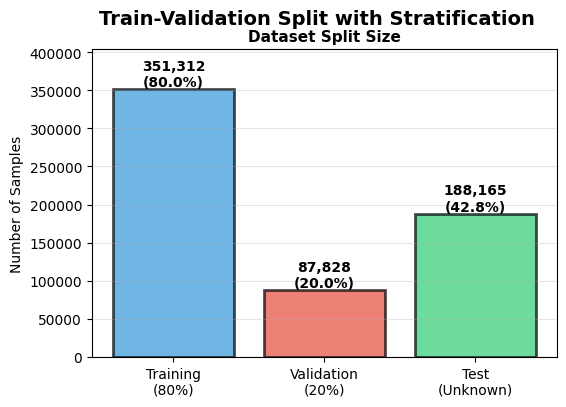

In [57]:
# VISUALIZATION: DATA SPLIT SUMMARY
fig = plt.figure(figsize=(6, 4))
gs = fig.add_gridspec(1, 1, hspace=0.3, wspace=0.3)
fig.suptitle('Train-Validation Split with Stratification', fontweight='bold', fontsize=14)

ax1 = fig.add_subplot(gs[0, 0])
split_labels = ['Training\n(80%)', 'Validation\n(20%)', 'Test\n(Unknown)']
split_sizes = [len(X_train), len(X_val), len(X_test)]
colors_split = ['#3498db', '#e74c3c', '#2ecc71']
bars1 = ax1.bar(split_labels, split_sizes, color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_title('Dataset Split Size', fontweight='bold', fontsize=11)
ax1.set_ylabel('Number of Samples')
ax1.set_ylim(0, max(split_sizes) * 1.15)

for bar, size in zip(bars1, split_sizes):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(size):,}\n({size/len(X)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax1.grid(alpha=0.3, axis='y')
plt.show()


## FEATURE SCALING WITH STANDARDSCALER

In [62]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# FIT on training data ONLY
scaler.fit(X_train)

# Store feature statistics for reference
feature_stats = pd.DataFrame({
    'Feature': X_train.columns,
    'Mean': scaler.mean_,
    'Std_Dev': scaler.scale_,
    'Variance': scaler.var_
})
print(feature_stats.to_string())


                   Feature         Mean     Std_Dev       Variance
0                     Year  2023.523412    1.025128       1.050888
1                  PitStop     0.136392    0.343204       0.117789
2                LapNumber    23.106717   16.963564     287.762508
3                    Stint     1.788906    0.949176       0.900935
4                 TyreLife    14.157534    9.807858      96.194075
5                 Position     9.627983    5.282836      27.908360
6              LapTime (s)    90.951166   20.165008     406.627542
7            LapTime_Delta    -3.774504   44.275425    1960.313282
8   Cumulative_Degradation   -25.663681   54.883196    3012.165213
9             RaceProgress     0.337584    0.253275       0.064148
10         Position_Change     0.102738    4.005495      16.043992
11        Compound_encoded     2.389395    0.714906       0.511090
12          Driver_encoded   362.164703  339.653329  115364.384194
13            Race_encoded    12.776059    7.540323      56.85

In [63]:
# TRANSFORM ALL DATASETS

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrames for better handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


In [64]:
# Verify scaling
print(f"  • Mean:          {X_train_scaled.mean().round(6)[:3].values}... (should be ~0)")
print(f"  • Std Dev:       {X_train_scaled.std().round(3)[:3].values}... (should be ~1)")

print(f"\nValidation data (scaled):")
print(f"  • Mean:          {X_val_scaled.mean().round(4)[:3].values}")
print(f"  • Std Dev:       {X_val_scaled.std().round(3)[:3].values}")

print(f"\nTest data (scaled):")
print(f"  • Mean:          {X_test_scaled.mean().round(4)[:3].values}")
print(f"  • Std Dev:       {X_test_scaled.std().round(3)[:3].values}")

  • Mean:          [-0. -0. -0.]... (should be ~0)
  • Std Dev:       [1. 1. 1.]... (should be ~1)

Validation data (scaled):
  • Mean:          [ 0.0006 -0.004  -0.0002]
  • Std Dev:       [0.999 0.996 0.998]

Test data (scaled):
  • Mean:          [ 0.0049 -0.0004 -0.0033]
  • Std Dev:       [1.    1.    1.002]


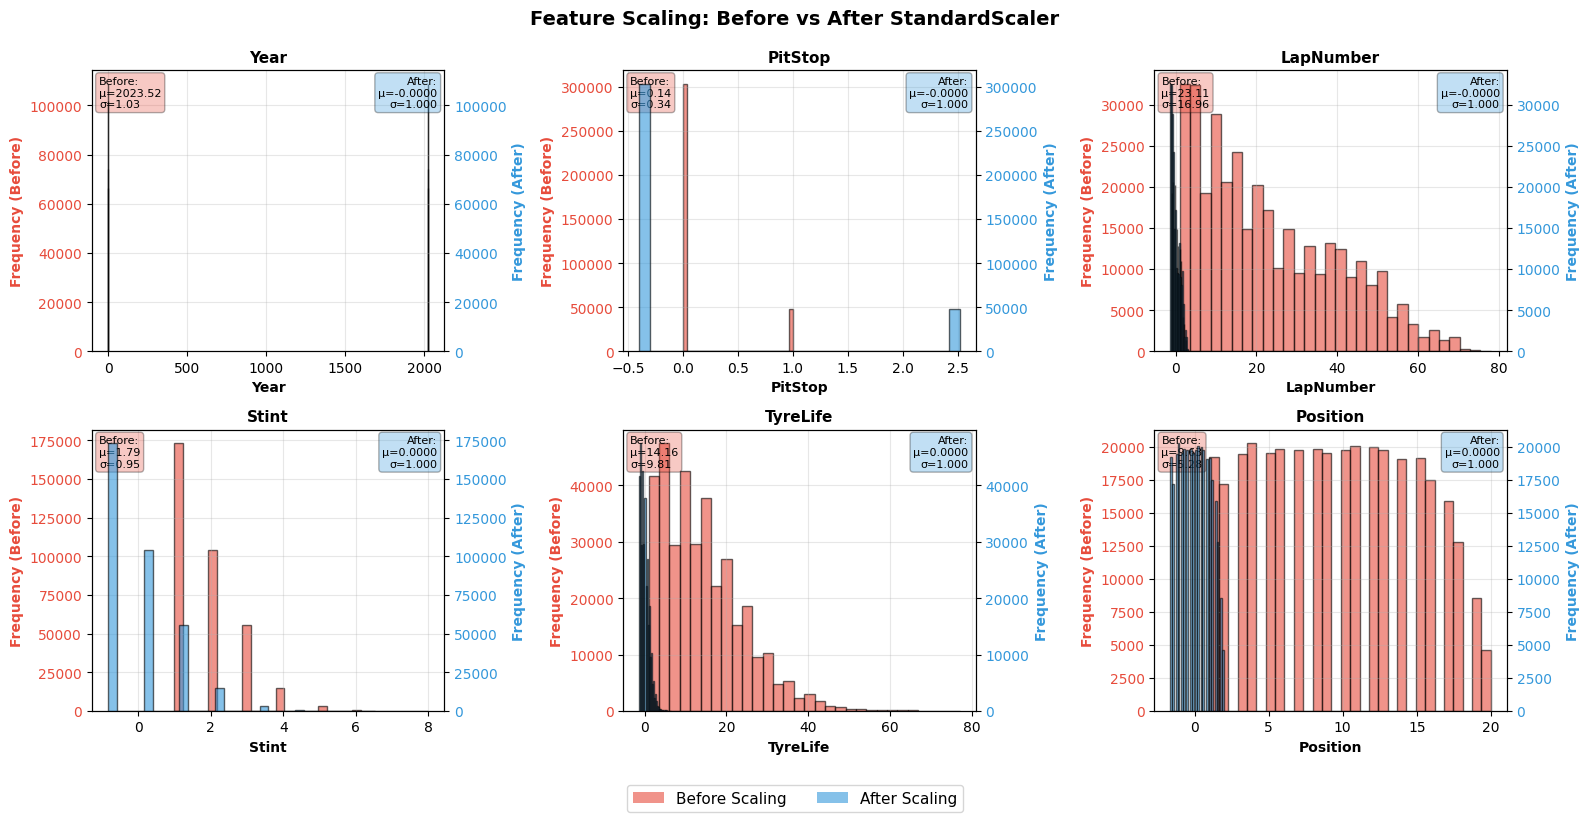

In [ ]:
# 3. VISUALIZATION: BEFORE & AFTER SCALING
sample_features = X_train.columns[:6]  # First 6 features

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Feature Scaling: Before vs After StandardScaler', fontweight='bold', fontsize=14)

for idx, feature in enumerate(sample_features):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Before scaling
    ax.hist(X_train[feature], bins=30, alpha=0.6, label='Before Scaling', color='#e74c3c', edgecolor='black')
    
    # After scaling (on secondary axis)
    ax2 = ax.twinx()
    ax2.hist(X_train_scaled[feature], bins=30, alpha=0.6, label='After Scaling', color='#3498db', edgecolor='black')
    
    ax.set_xlabel(f'{feature}', fontweight='bold')
    ax.set_ylabel('Frequency (Before)', color='#e74c3c', fontweight='bold')
    ax2.set_ylabel('Frequency (After)', color='#3498db', fontweight='bold')
    ax.tick_params(axis='y', labelcolor='#e74c3c')
    ax2.tick_params(axis='y', labelcolor='#3498db')
    ax.set_title(f'{feature}', fontweight='bold', fontsize=11)
    ax.grid(alpha=0.3)
    
    # Add statistics
    before_stats = f"μ={X_train[feature].mean():.2f}\nσ={X_train[feature].std():.2f}"
    after_stats = f"μ={X_train_scaled[feature].mean():.4f}\nσ={X_train_scaled[feature].std():.3f}"
    
    ax.text(0.02, 0.98, f"Before:\n{before_stats}", transform=ax.transAxes,
           verticalalignment='top', fontsize=8, bbox=dict(boxstyle='round', facecolor='#e74c3c', alpha=0.3))
    ax2.text(0.98, 0.98, f"After:\n{after_stats}", transform=ax2.transAxes,
            verticalalignment='top', horizontalalignment='right', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='#3498db', alpha=0.3))

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', alpha=0.6, label='Before Scaling'),
                  Patch(facecolor='#3498db', alpha=0.6, label='After Scaling')]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, fontsize=11)

plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.show()


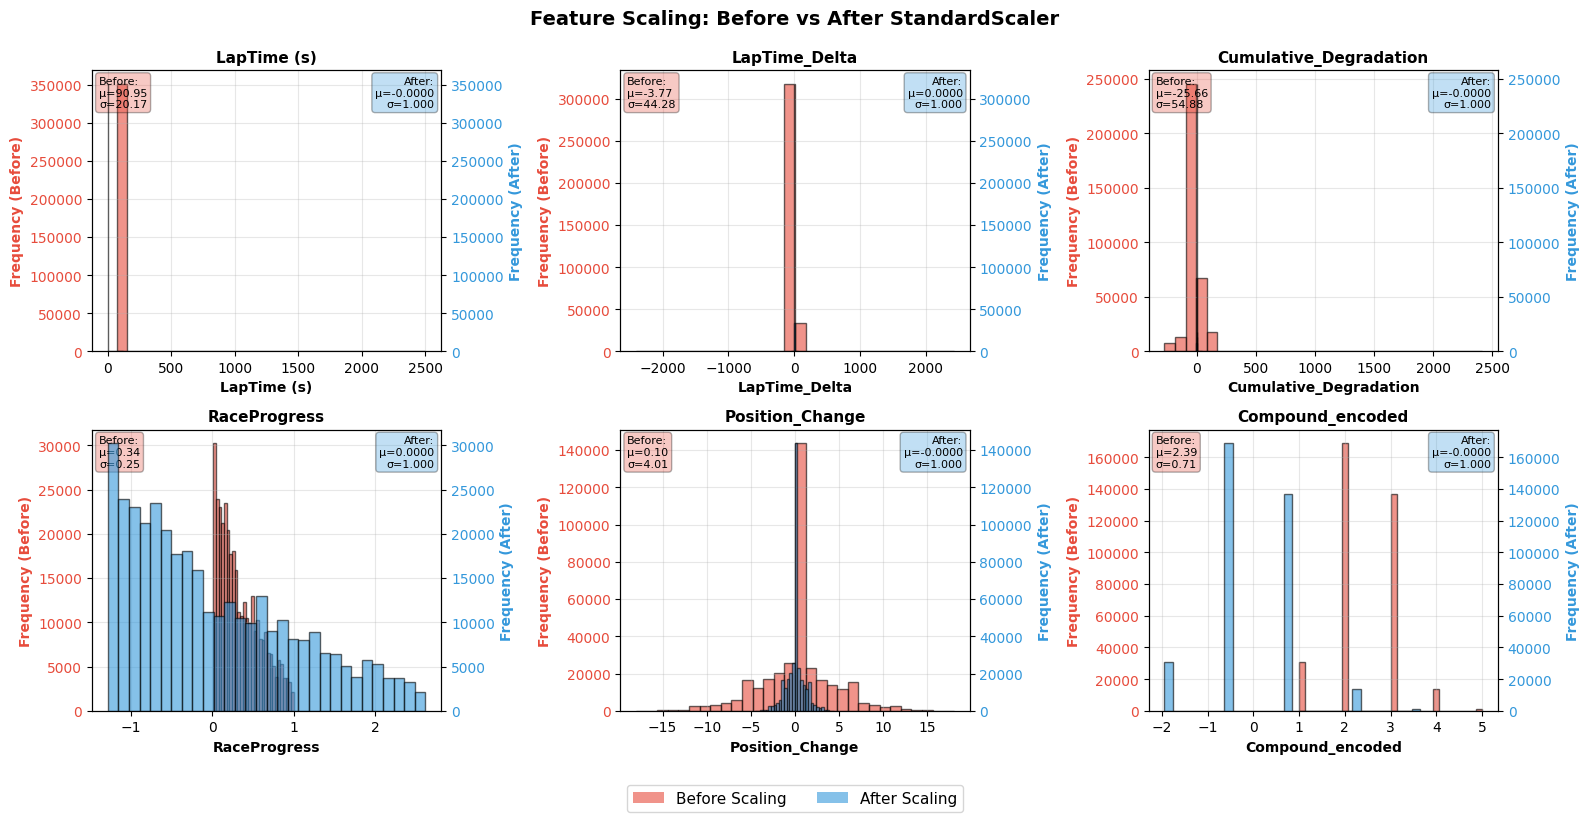

In [66]:
### 3. VISUALIZATION: BEFORE & AFTER SCALING
sample_features = X_train.columns[6:12]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Feature Scaling: Before vs After StandardScaler', fontweight='bold', fontsize=14)

for idx, feature in enumerate(sample_features):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Before scaling
    ax.hist(X_train[feature], bins=30, alpha=0.6, label='Before Scaling', color='#e74c3c', edgecolor='black')
    
    # After scaling (on secondary axis)
    ax2 = ax.twinx()
    ax2.hist(X_train_scaled[feature], bins=30, alpha=0.6, label='After Scaling', color='#3498db', edgecolor='black')
    
    ax.set_xlabel(f'{feature}', fontweight='bold')
    ax.set_ylabel('Frequency (Before)', color='#e74c3c', fontweight='bold')
    ax2.set_ylabel('Frequency (After)', color='#3498db', fontweight='bold')
    ax.tick_params(axis='y', labelcolor='#e74c3c')
    ax2.tick_params(axis='y', labelcolor='#3498db')
    ax.set_title(f'{feature}', fontweight='bold', fontsize=11)
    ax.grid(alpha=0.3)
    
    # Add statistics
    before_stats = f"μ={X_train[feature].mean():.2f}\nσ={X_train[feature].std():.2f}"
    after_stats = f"μ={X_train_scaled[feature].mean():.4f}\nσ={X_train_scaled[feature].std():.3f}"
    
    ax.text(0.02, 0.98, f"Before:\n{before_stats}", transform=ax.transAxes,
           verticalalignment='top', fontsize=8, bbox=dict(boxstyle='round', facecolor='#e74c3c', alpha=0.3))
    ax2.text(0.98, 0.98, f"After:\n{after_stats}", transform=ax2.transAxes,
            verticalalignment='top', horizontalalignment='right', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='#3498db', alpha=0.3))

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', alpha=0.6, label='Before Scaling'),
                  Patch(facecolor='#3498db', alpha=0.6, label='After Scaling')]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, fontsize=11)

plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.show()

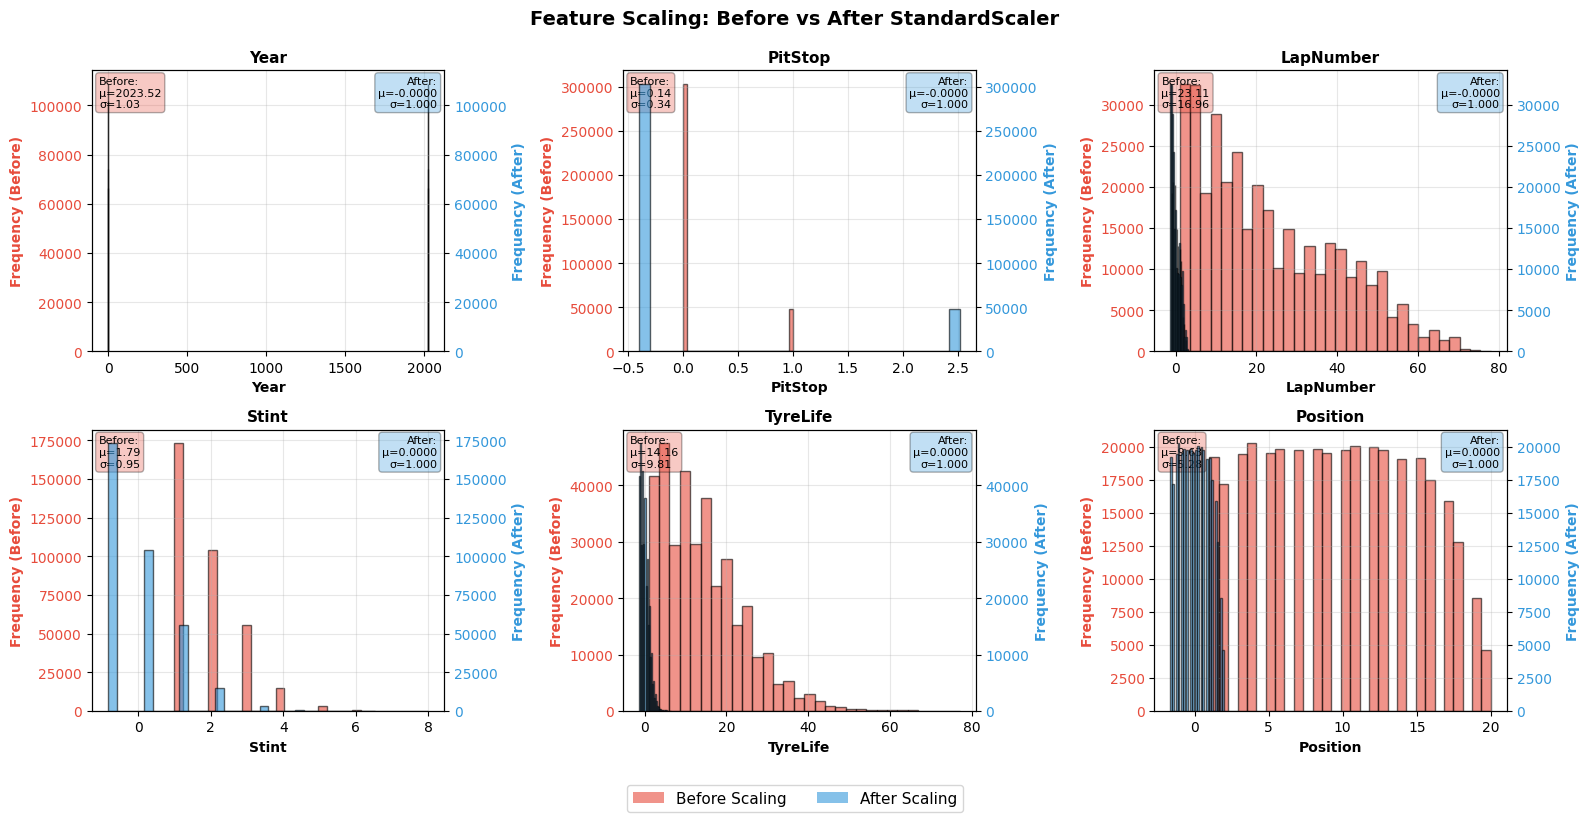

In [68]:
### 3. VISUALIZATION: BEFORE & AFTER SCALING
sample_features = X_train.columns[:6]  # First 6 features

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Feature Scaling: Before vs After StandardScaler', fontweight='bold', fontsize=14)

for idx, feature in enumerate(sample_features):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Before scaling
    ax.hist(X_train[feature], bins=30, alpha=0.6, label='Before Scaling', color='#e74c3c', edgecolor='black')
    
    # After scaling (on secondary axis)
    ax2 = ax.twinx()
    ax2.hist(X_train_scaled[feature], bins=30, alpha=0.6, label='After Scaling', color='#3498db', edgecolor='black')
    
    ax.set_xlabel(f'{feature}', fontweight='bold')
    ax.set_ylabel('Frequency (Before)', color='#e74c3c', fontweight='bold')
    ax2.set_ylabel('Frequency (After)', color='#3498db', fontweight='bold')
    ax.tick_params(axis='y', labelcolor='#e74c3c')
    ax2.tick_params(axis='y', labelcolor='#3498db')
    ax.set_title(f'{feature}', fontweight='bold', fontsize=11)
    ax.grid(alpha=0.3)
    
    # Add statistics
    before_stats = f"μ={X_train[feature].mean():.2f}\nσ={X_train[feature].std():.2f}"
    after_stats = f"μ={X_train_scaled[feature].mean():.4f}\nσ={X_train_scaled[feature].std():.3f}"
    
    ax.text(0.02, 0.98, f"Before:\n{before_stats}", transform=ax.transAxes,
           verticalalignment='top', fontsize=8, bbox=dict(boxstyle='round', facecolor='#e74c3c', alpha=0.3))
    ax2.text(0.98, 0.98, f"After:\n{after_stats}", transform=ax2.transAxes,
            verticalalignment='top', horizontalalignment='right', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='#3498db', alpha=0.3))

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', alpha=0.6, label='Before Scaling'),
                  Patch(facecolor='#3498db', alpha=0.6, label='After Scaling')]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, fontsize=11)

plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.show()

### MODEL TRAINING WITH PROBABILITY ESTIMATES

In [73]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (StratifiedKFold, GridSearchCV, 
                                     cross_validate, cross_val_score)
from sklearn.metrics import (roc_auc_score, log_loss, f1_score, 
                            precision_score, recall_score, 
                            roc_curve, auc, confusion_matrix, 
                            classification_report)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler

### MODEL 1: LOGISTIC REGRESSION (BASELINE)

In [74]:
# Logistic Regression with class_weight='balanced' for imbalance
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=4, solver='lbfgs')

# Cross-validation with multiple metrics
scoring = {
    'auc_roc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'log_loss': 'neg_log_loss'
}

cv_results = cross_validate(lr, X_train_scaled, y_train, 
                           cv=skf, scoring=scoring, 
                           return_train_score=True, n_jobs=-1)

# Extract metrics
train_auc = cv_results['train_auc_roc'].mean()
val_auc = cv_results['test_auc_roc'].mean()
train_f1 = cv_results['train_f1'].mean()
val_f1 = cv_results['test_f1'].mean()
train_precision = cv_results['train_precision'].mean()
val_precision = cv_results['test_precision'].mean()
train_recall = cv_results['train_recall'].mean()
val_recall = cv_results['test_recall'].mean()

print(f"LOGISTIC REGRESSION CROSS-VALIDATION RESULTS:")
print(f"   AUC-ROC:     Train={train_auc:.4f}  |  Val={val_auc:.4f}")
print(f"   F1-Score:    Train={train_f1:.4f}  |  Val={val_f1:.4f}")
print(f"   Precision:   Train={train_precision:.4f}  |  Val={val_precision:.4f}")
print(f"   Recall:      Train={train_recall:.4f}  |  Val={val_recall:.4f}")

# Train final model on full training set
lr.fit(X_train_scaled, y_train)

# Get probability predictions
y_val_pred_proba_lr = lr.predict_proba(X_val_scaled)[:, 1]
y_test_pred_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Final evaluation on validation set
val_auc_final = roc_auc_score(y_val, y_val_pred_proba_lr)
val_logloss_final = log_loss(y_val, y_val_pred_proba_lr)
y_val_pred_lr = lr.predict(X_val_scaled)
val_f1_final = f1_score(y_val, y_val_pred_lr)

print(f"FINAL VALIDATION PERFORMANCE:")
print(f"   AUC-ROC:     {val_auc_final:.4f}")
print(f"   Log-Loss:    {val_logloss_final:.4f}")
print(f"   F1-Score:    {val_f1_final:.4f}")

model_results['Logistic Regression'] = {
    'model': lr,
    'cv_auc': val_auc,
    'val_auc': val_auc_final,
    'val_f1': val_f1_final,
    'val_logloss': val_logloss_final,
    'y_val_pred_proba': y_val_pred_proba_lr,
    'y_test_pred_proba': y_test_pred_proba_lr
}

LOGISTIC REGRESSION CROSS-VALIDATION RESULTS:
   AUC-ROC:     Train=0.8271  |  Val=0.8271
   F1-Score:    Train=0.5522  |  Val=0.5523
   Precision:   Train=0.4308  |  Val=0.4310
   Recall:      Train=0.7689  |  Val=0.7688
FINAL VALIDATION PERFORMANCE:
   AUC-ROC:     0.8279
   Log-Loss:    0.5254
   F1-Score:    0.5533
